In [40]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
# Function to generate energies and momenta of daughter particles from the dacay of a parent particle at rest
def decay_generator(M, m):
    # Generate energies and momenta
    E = E = M/2
    p_val = 0.5 * np.sqrt(M**2 - 4* m**2)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)

    px = p_val * np.sin(theta) * np.cos(phi)
    py = p_val * np.sin(theta) * np.sin(phi)
    pz = p_val * np.cos(theta)

    p1 = np.array([E, px, py, pz])
    p2 = np.array([E, -px, -py, -pz])

    return p1, p2

def invariant_mass(p1, p2):
    E = p1[0] + p2[0]
    px = p1[1] + p2[1]
    py = p1[2] + p2[2]
    pz = p1[3] + p2[3]

    return np.sqrt(E**2 - px**2 - py**2 - pz**2)

In [42]:
particles = {
  "J/psi": 3.1,
  "p": 0.938,
  "mu": 0.105,
  "e" : 0.000511,
  "K_0" : 0.498,
  "K_+" : 0.494
}

In [43]:
M_jpsi = 3.097
m_p = 0.938

N_sig = 20000
masses_sig = []

for _ in range(N_sig):
    p1, p2 = decay_generator(M_jpsi, m_p)
    m = invariant_mass(p1, p2)
    masses_sig.append(m)

In [44]:
m_mu = 0.105
M_min = 2 * m_mu
M_max = 7.0

def sample_M():
    while True:
        M = np.random.exponential(scale=1.0) + M_min
        if M < M_max:
            return M

N_bkg = 100000
masses_bkg = []

for _ in range(N_bkg):
    M = sample_M()
    p1, p2 = decay_generator(M, m_mu)
    m = invariant_mass(p1, p2)
    masses_bkg.append(m)

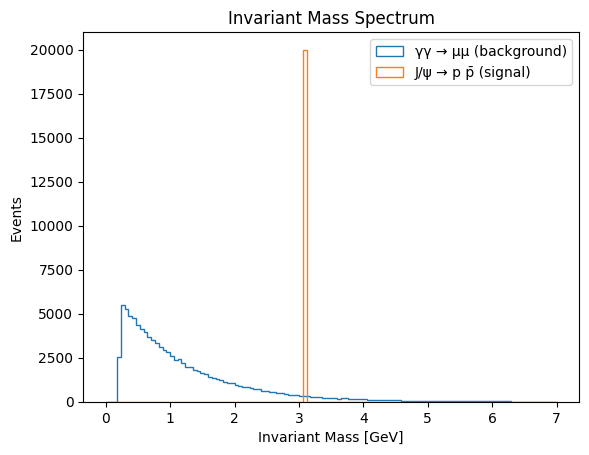

In [45]:
bins = np.linspace(0, 7, 120)

plt.hist(masses_bkg, bins=bins, histtype='step', label='γγ → μμ (background)')
plt.hist(masses_sig, bins=bins, histtype='step', label='J/ψ → p p̄ (signal)')

plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Events")
plt.title("Invariant Mass Spectrum")
plt.legend()
plt.show()